In [27]:
import pandas as pd
import glob
import re
import matplotlib.pyplot as plt
import os

In [28]:
base_dir = "latency_output/20260418_123653/2026_04_18_12"

files = []

for root, dirs, filenames in os.walk(base_dir):
    for name in filenames:
        if "part-" in name:   # Spark files are usually part-00000...
            files.append(os.path.join(root, name))

print("Found files:", len(files))
for f in files[:10]:
    print(f)

Found files: 6
latency_output/20260418_123653/2026_04_18_12/part-5415e899-1a56-4a93-9a35-cadd99289e35-1.inprogress.c17ddf05-0302-465a-ab23-87421a7fd709
latency_output/20260418_123653/2026_04_18_12/part-9cb38e50-e360-48fb-a1ab-b6ed042aa10b-1.inprogress.5a234bcc-098b-491f-b160-3e2021308dca
latency_output/20260418_123653/2026_04_18_12/part-9cb38e50-e360-48fb-a1ab-b6ed042aa10b-0.inprogress.18e614e9-80ad-4fae-a6f1-b83679c5f831
latency_output/20260418_123653/2026_04_18_12/part-5415e899-1a56-4a93-9a35-cadd99289e35-0.inprogress.6f938322-e2d0-4096-b393-887c25416334
latency_output/20260418_123653/2026_04_18_12/part-23ec76d7-ef9f-4546-9e6d-b9ce018bb433-0.inprogress.69edbf5b-3e13-443e-a938-72a176543806
latency_output/20260418_123653/2026_04_18_12/part-23ec76d7-ef9f-4546-9e6d-b9ce018bb433-1.inprogress.3197e7bc-42fd-4fdb-981f-e43282cf83e3


In [29]:
pwd

'/Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/flink/flink_with_kafka'

In [30]:
rows = []
pattern = re.compile(
    r"window_start=(.*?), window_end=(.*?), records=(\d+), "
    r"avg_latency_ms=([\d.]+), p50_ms=(\d+), p95_ms=(\d+), p99_ms=(\d+)"
)

In [31]:
for file in files:
    print(file)
    with open(file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                rows.append({
                    "window_start": match.group(1),
                    "window_end": match.group(2),
                    "records": int(match.group(3)),
                    "avg_latency_ms": float(match.group(4)),
                    "p50_ms": int(match.group(5)),
                    "p95_ms": int(match.group(6)),
                    "p99_ms": int(match.group(7))
                })

latency_output/20260418_123653/2026_04_18_12/part-5415e899-1a56-4a93-9a35-cadd99289e35-1.inprogress.c17ddf05-0302-465a-ab23-87421a7fd709
latency_output/20260418_123653/2026_04_18_12/part-9cb38e50-e360-48fb-a1ab-b6ed042aa10b-1.inprogress.5a234bcc-098b-491f-b160-3e2021308dca
latency_output/20260418_123653/2026_04_18_12/part-9cb38e50-e360-48fb-a1ab-b6ed042aa10b-0.inprogress.18e614e9-80ad-4fae-a6f1-b83679c5f831
latency_output/20260418_123653/2026_04_18_12/part-5415e899-1a56-4a93-9a35-cadd99289e35-0.inprogress.6f938322-e2d0-4096-b393-887c25416334
latency_output/20260418_123653/2026_04_18_12/part-23ec76d7-ef9f-4546-9e6d-b9ce018bb433-0.inprogress.69edbf5b-3e13-443e-a938-72a176543806
latency_output/20260418_123653/2026_04_18_12/part-23ec76d7-ef9f-4546-9e6d-b9ce018bb433-1.inprogress.3197e7bc-42fd-4fdb-981f-e43282cf83e3


In [32]:
rows[:2]

[{'window_start': '2026-04-18 12:38:50',
  'window_end': '2026-04-18 12:38:55',
  'records': 4479,
  'avg_latency_ms': 719.55,
  'p50_ms': 716,
  'p95_ms': 1302,
  'p99_ms': 1392},
 {'window_start': '2026-04-18 12:38:55',
  'window_end': '2026-04-18 12:39:00',
  'records': 671,
  'avg_latency_ms': 1423.69,
  'p50_ms': 1360,
  'p95_ms': 1917,
  'p99_ms': 1988}]

In [33]:
# --------------------------------------------------
# 2. Convert to DataFrame
# --------------------------------------------------
df = pd.DataFrame(rows)

# convert timestamps
df["window_start"] = pd.to_datetime(df["window_start"])
df["window_end"] = pd.to_datetime(df["window_end"])

# --------------------------------------------------
# 3. IMPORTANT: remove duplicates (you have repeated windows)
# --------------------------------------------------
df = df.groupby("window_start").mean(numeric_only=True).reset_index()

# recompute window_end (optional consistency)
df["window_end"] = df["window_start"] + pd.Timedelta(seconds=5)

# --------------------------------------------------
# 4. Sort
# --------------------------------------------------
df = df.sort_values("window_start")
df["window_index"] = range(len(df))

# convert to seconds (5s window size)
df["time_sec"] = df["window_index"] * 5

In [34]:
df["window_start"] = pd.to_datetime(df["window_start"])
df = df.sort_values("window_start")

# convert to relative time (seconds from start)
df["time_sec"] = (df["window_start"] - df["window_start"].min()).dt.total_seconds()

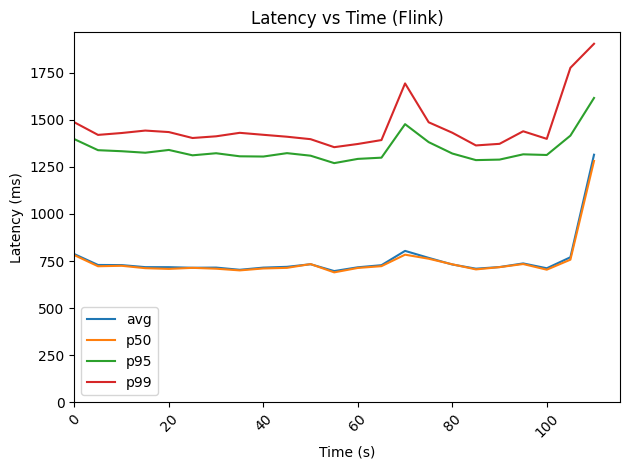

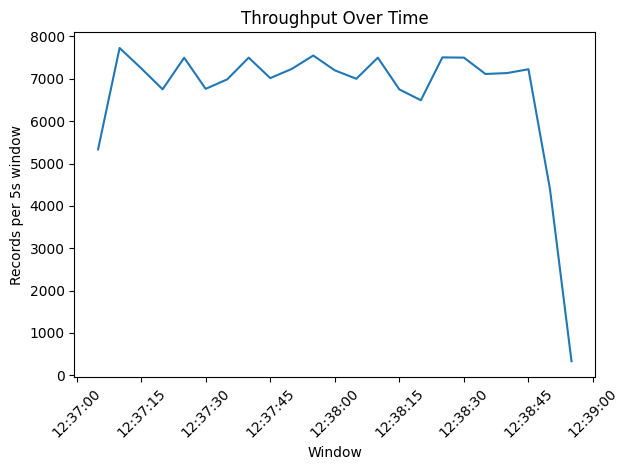

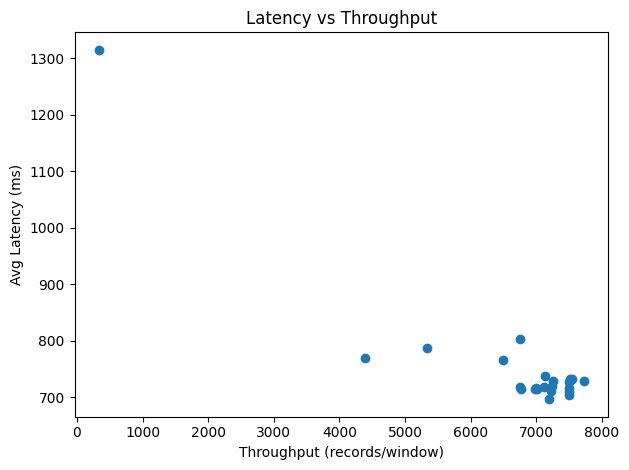

In [36]:
# --------------------------------------------------
# 5. Plot 1: Latency trends
# --------------------------------------------------
plt.figure()

plt.plot(df["time_sec"], df["avg_latency_ms"], label="avg")
plt.plot(df["time_sec"], df["p50_ms"], label="p50")
plt.plot(df["time_sec"], df["p95_ms"], label="p95")
plt.plot(df["time_sec"], df["p99_ms"], label="p99")

plt.legend()
plt.title("Latency vs Time (Flink)")
plt.xlabel("Time (s)")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=45)

plt.xlim(left=0)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Plot 2: Throughput
# --------------------------------------------------
plt.figure()
plt.plot(df["window_start"], df["records"])
plt.title("Throughput Over Time")
plt.xlabel("Window")
plt.ylabel("Records per 5s window")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 7. Plot 3: Latency vs throughput correlation (optional but useful)
# --------------------------------------------------
plt.figure()
plt.scatter(df["records"], df["avg_latency_ms"])
plt.title("Latency vs Throughput")
plt.xlabel("Throughput (records/window)")
plt.ylabel("Avg Latency (ms)")
plt.tight_layout()
plt.show()